# **[IA03] Imbalanced Data on *fetal-health* dataset**

##### Francisco Campos (FEUP/FCUP, M.IA)

## **Introduction**

In this tutorial, we will analyse the [Fetal Health](https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification) dataset. The purpose of this tutorial is to overcome the imbalanced nature of the dataset. We will persue the following steps:
1. **Data profiling** and preprocessing
2. Decide **performance metric** to optimize
3. Train a **model on the imbalanced dataset**
4. Apply **techniques to overcome the imbalance** (oversampling, undersampling, SMOTE, ADASYN)
5. Re-train the **model on the balanced dataset**
6. **Compare** the results

### **Initial Imports**

In [21]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

## **Loadind the dataset**

In [22]:
df = pd.read_csv("fetal_health.csv")

In [23]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [24]:
df.shape

(2126, 22)

## **Dataset Characterization**

This dataset include data to classify the health of a fetus as Normal, Suspect or Pathological using CTG data. These are the features included in the dataset:

- **baseline value**: Average *fetal heart rate (FHR)* in beats per minute during stable periods.  
- **accelerations**: Count of temporary increases in FHR above the baseline, indicating fetal health.  
- **fetal_movement**: Number of observed fetal movements, reflecting activity levels.  
- **uterine_contractions**: Number of detected uterine contractions during monitoring.  
- **light_decelerations**: Frequency of slight FHR decreases below the baseline.  
- **severe_decelerations**: Instances of significant drops in FHR, possibly signaling distress.  
- **prolongued_decelerations**: Number of extended periods where FHR remains below baseline levels.  
- **abnormal_short_term_variability**: Percentage of time showing irregular beat-to-beat FHR changes.  
- **mean_value_of_short_term_variability**: Average FHR fluctuations over short periods.  
- **percentage_of_time_with_abnormal_long_term_variability**: Portion of time with irregular FHR patterns over longer durations.  
- **mean_value_of_long_term_variability**: Average FHR changes over longer monitoring periods.  
- **histogram_width**: Range of FHR values observed during the monitoring session.  
- **histogram_min**: Lowest FHR value recorded.  
- **histogram_max**: Highest FHR value recorded.  
- **histogram_number_of_peaks**: Count of distinct peaks in the FHR value distribution.  
- **histogram_number_of_zeroes**: Instances where no FHR value was detected.  
- **histogram_mode**: Most frequently recorded FHR value.  
- **histogram_mean**: Average of all recorded FHR values.  
- **histogram_median**: Middle FHR value when all measurements are ordered.  
- **histogram_variance**: Degree to which FHR values deviate from their mean.  
- **histogram_tendency**: General trend of FHR values (increasing or decreasing).  
- **fetal_health**: Target variable classifying fetal condition into normal (1), suspect (2), or pathological (3).  

## **Data Profiling and Preprocessing**

### **Data Cleaning**

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [26]:
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [27]:
print("Dataset Size: ", df.shape)
print("===Target Distribution:===", df["fetal_health"].value_counts(), sep='\n')
print("==========================")
print("Missing Values: ", df.isna().sum().sum())
print("Duplicated Values: ", df.duplicated().sum())

Dataset Size:  (2126, 22)
===Target Distribution:===
fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64
Missing Values:  0
Duplicated Values:  13


<Axes: xlabel='fetal_health'>

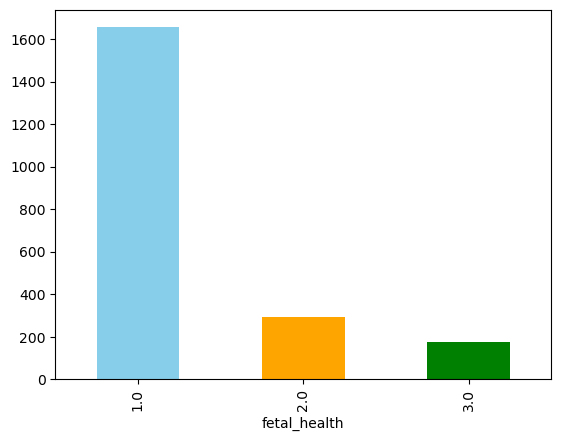

In [28]:
df["fetal_health"].value_counts().plot(kind='bar', color=['skyblue', 'orange', 'green'])

#### **Main Insights**:
- All columns are numerical (no need to encode categorical variables)
- There are 13 duplicate rows in the dataset (we will remove them) 
- There are no missing values in the dataset (we will not need to impute missing values)
- There is a large variation in the different column values (we need to standardise or normalise the data)
- There is a class imbalance in the target variable (we will need to address this)

In [29]:
df.drop_duplicates(inplace=True)
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


### Feature Selection

As it is possible to see, this dataset has a lot o features, so we need to select the most relevant ones. 

We will do a correlation analysis to see which features are more correlated with each other. The idea is to remove one of the features that are highly correlated with another one, to avoid multicollinearity.

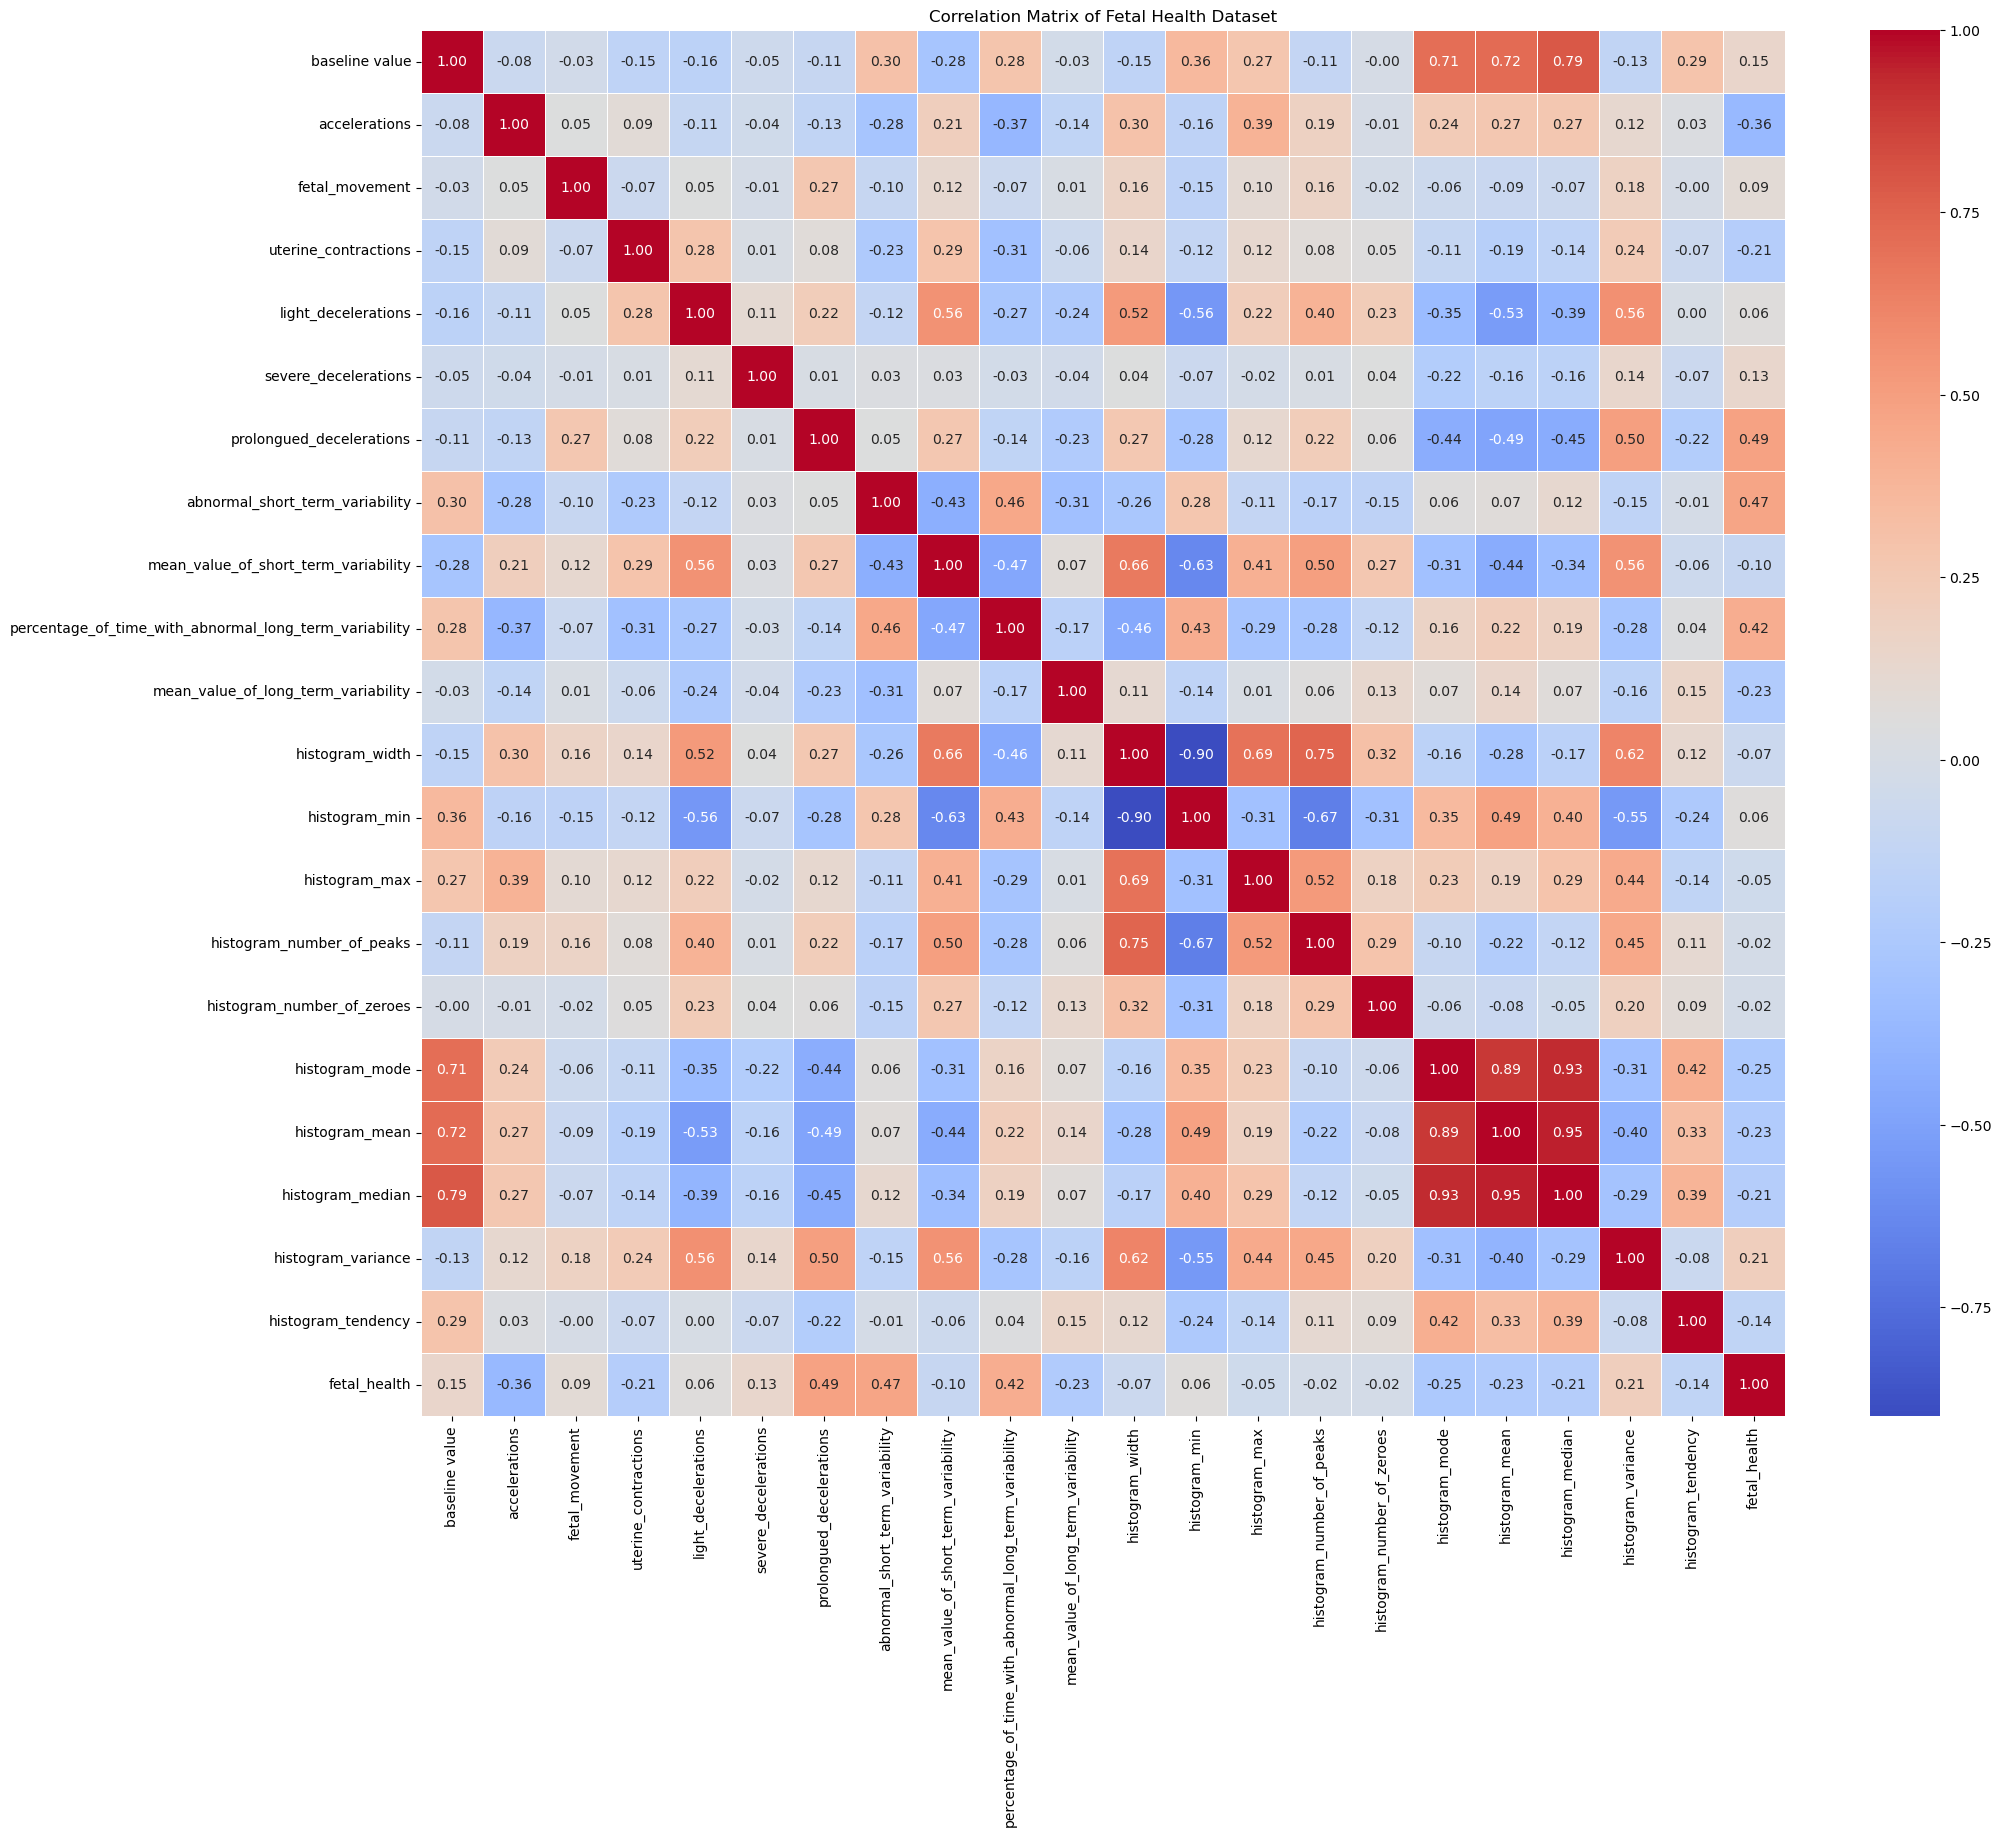

In [30]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(22, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)

# Set the title
plt.title('Correlation Matrix of Fetal Health Dataset')

# Show the plot
plt.show()

#### **Main Insights**:
- We should remove the features that are highly correlated with each other to avoid multicollinearity. These features are:
  - *histogram_mean* and *histogram_median* (correlation = 0.95)
  - *histogram_mean* and *histogram_mode* (correlation = 0.89)
  - *histogram_median* and *histogram_mode* (correlation = 0.93)
  - *histogram_min* and *histogram_width* (correlation = -0.90)

In [31]:
df.drop(columns=['histogram_mean', 'histogram_mode', 'histogram_min'], inplace=True)
print(df.columns)

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_median', 'histogram_variance',
       'histogram_tendency', 'fetal_health'],
      dtype='object')


### Ploting

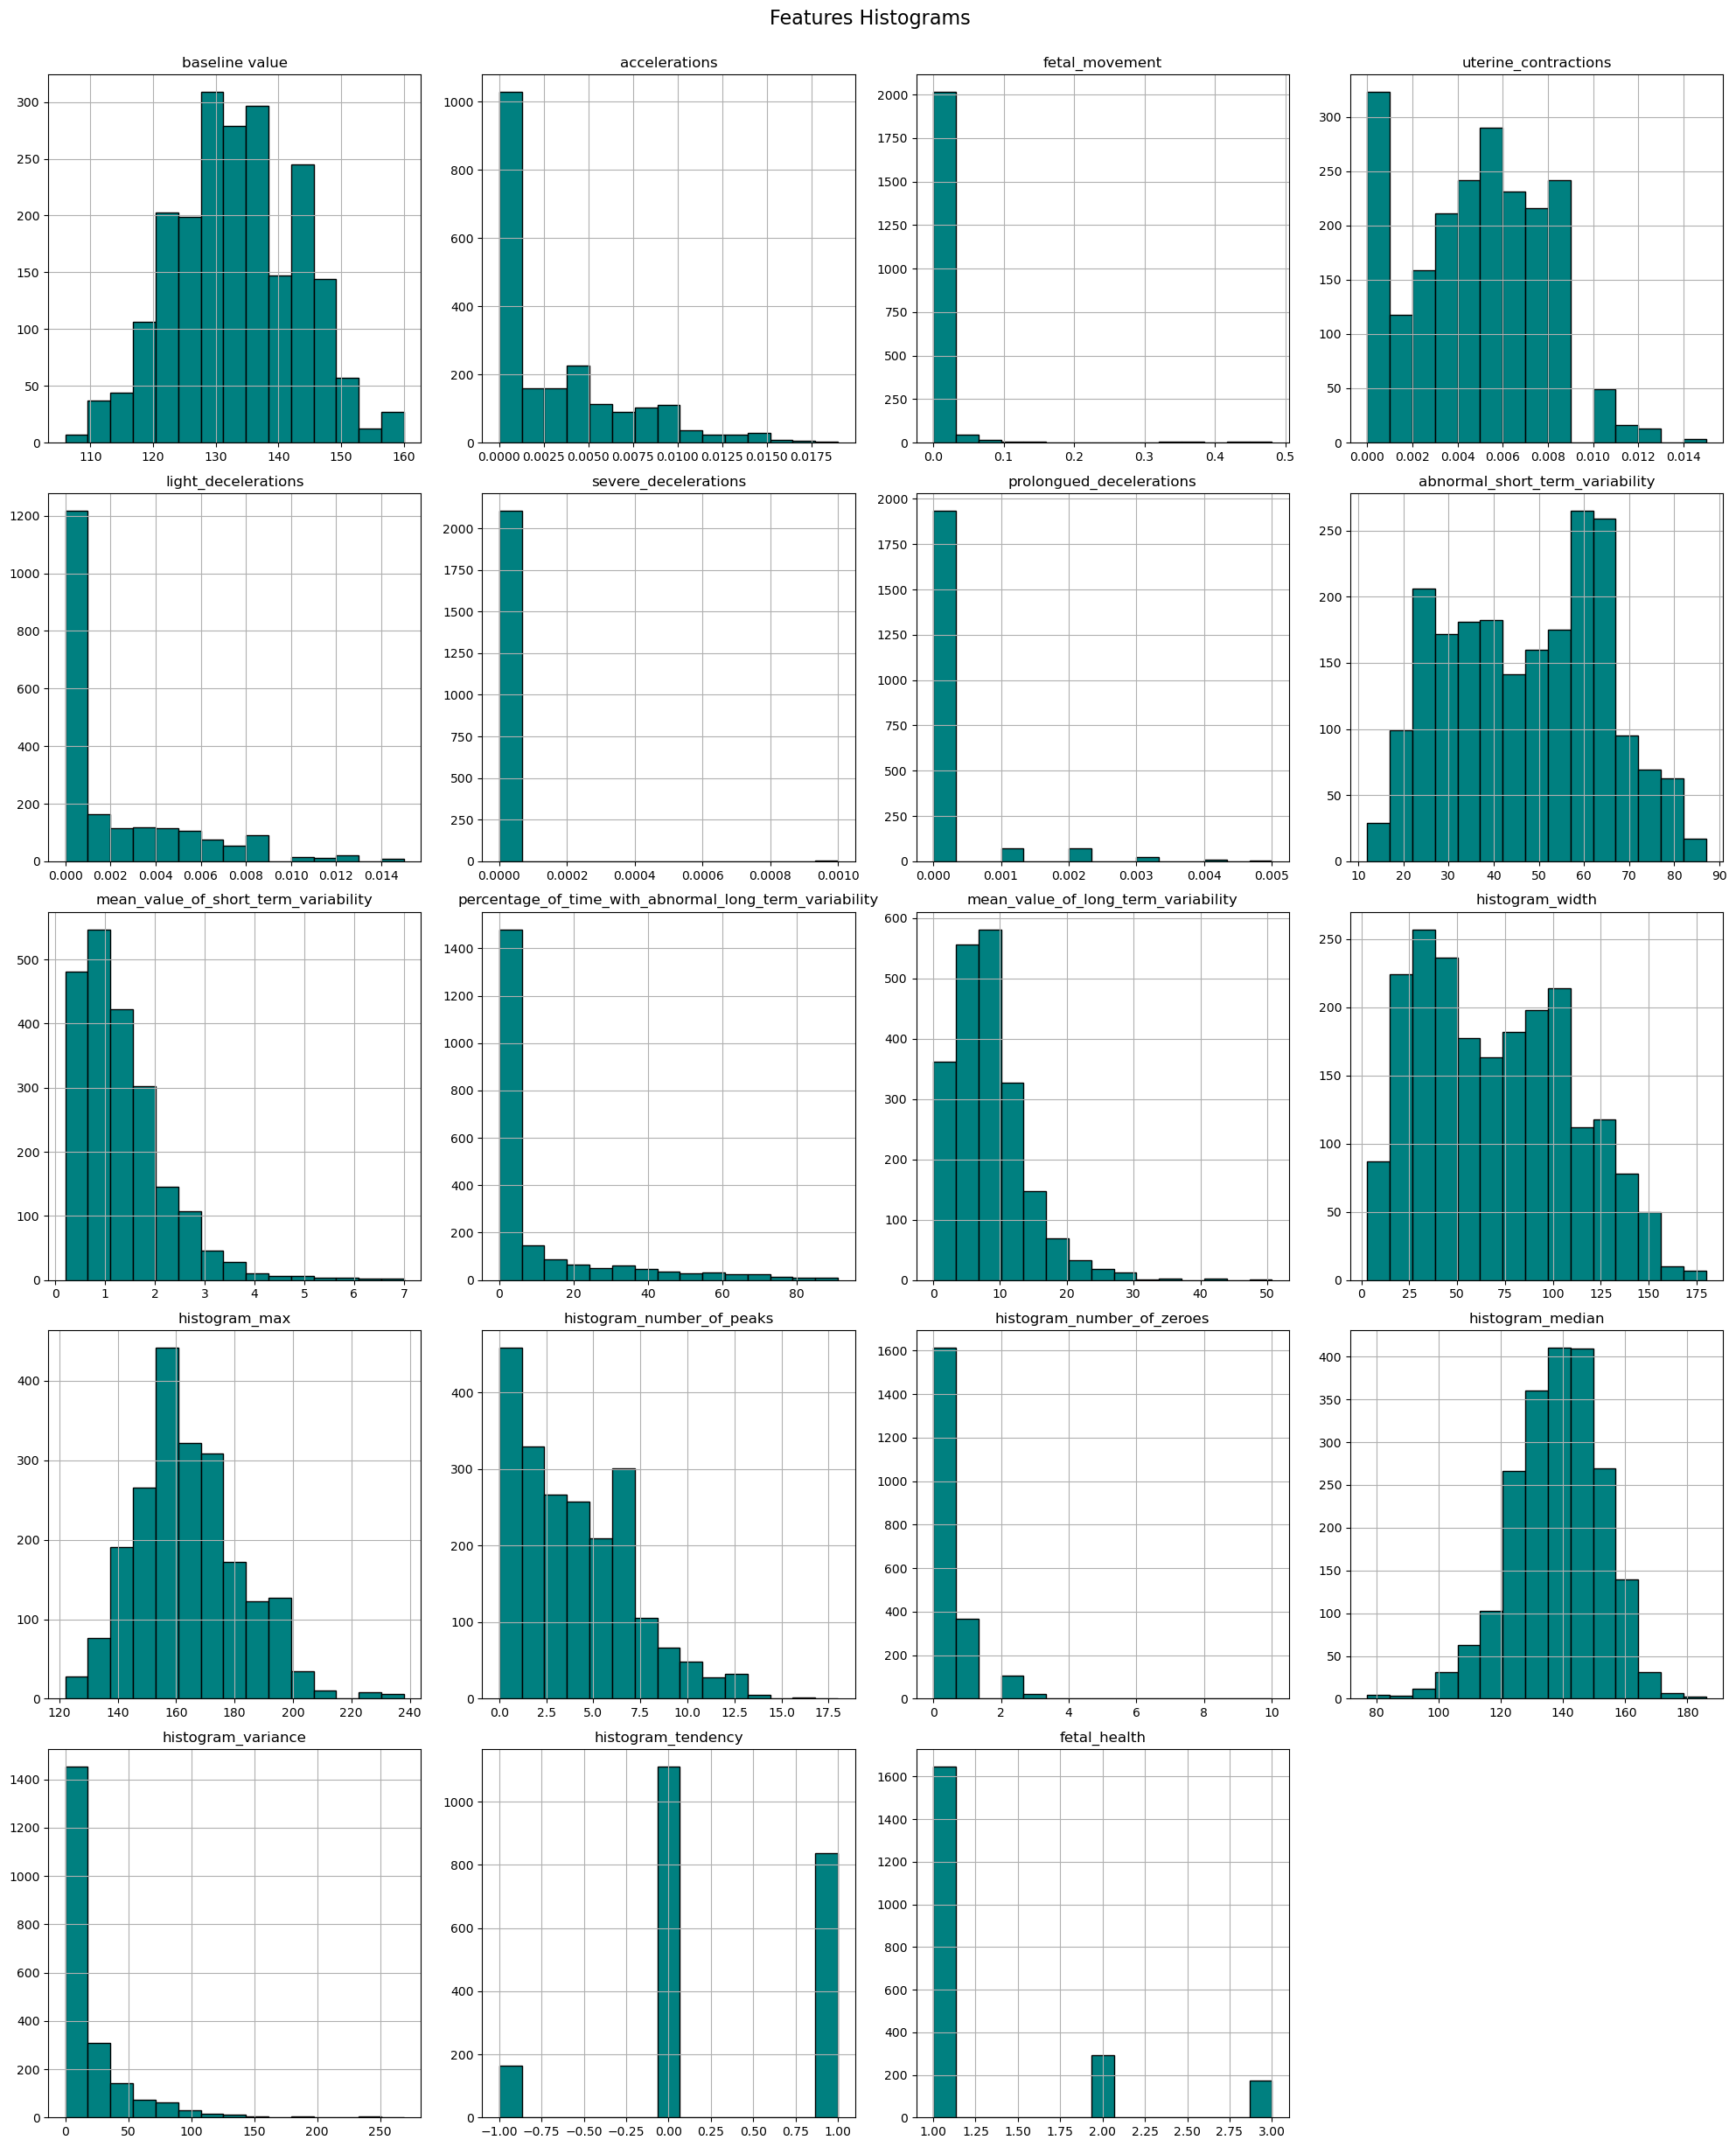

In [32]:
df.hist(figsize=(20, 25), bins=15, color='teal', edgecolor='black')

plt.suptitle('Features Histograms', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## **Precision Metrics Analysis**

When we talk about precision metrics, we are talking about the metrics that are used to evaluate the performance of a model. In this case, we will use the following metrics:
- **Accuracy**: The ratio of correctly predicted observation to the total observations.
- **Precision**: The ratio of correctly predicted positive observations to the total predicted positive observations.
- **Recall**: The ratio of correctly predicted positive observations to the all observations in actual class.
- **F1 Score**: The weighted average of Precision and Recall. Therefore, this score takes both false positives and false negatives into account. It is a good way to show that a classifer has a good value for both recall and precision.
- **ROC AUC Score**: The ROC curve is a graphical representation of the true positive rate against the false positive rate for the different possible cutpoints of a diagnostic test. The AUC is the area under the ROC curve.
- **PR AUC Score**: The precision-recall curve shows the tradeoff between precision and recall for different threshold. A high area under the curve represents both high recall and high precision, where high precision relates to a low false positive rate, and high recall relates to a low false negative rate.

### **Best Metrics to Optimize**

So that we can choose the best metrics to optimize, we need to understand the problem that we are trying to solve. In this case, we are trying to classify the health of a fetus as `Normal`, `Suspect` or `Pathological`.
- In the medical field, a model that is able to correctly identify if a fetus is `Pathological` increases the chances of a successful treatment. For instance, if a fetus is classified as `Normal` when it is actually `Pathological`, the consequences can be fatal. Therefore, we want to minimize the number of False Negatives (Pathological classified as Normal).
- At the same time, we don't want to spend resources on a fetus that is classified as `Pathological`, but is suppose to be `Normal`. Therefore, we also want to minimize the number of False Positives (Normal classified as Pathological).

In imbalance datasets, Accuracy is not a good metric to optimize, because it can be misleading. For instance, if we have 90% of the data from the Normal class and 10% from the Pathological class, a model that predicts all observations as Normal will have an accuracy of 90%, but it will not be a good model.

Regarding precision, this metric is also not a good metric to optimize, because it doesn't take into account the False Negatives. Therefore, we will not use this metric.

Recall is a good metric to optimize, because it takes into account the False Negatives. However, it would be better to use a metric that also takes into account the False Positives, and can give us a balance between the two. Therefore, since the most important task is to minimize the False Negatives, we will consider Recall as one of the metrics to optimize, but we will use another metric that takes into account both False Positives and False Negatives.

The F1 Score is a good metric to optimize, because it takes into account both False Positives and False Negatives. Therefore, we will use this metric to optimize the model.

In short, `Recall` and `F1 Score` are the best metrics to optimize, so we will use these metrics to classify the models.

## **Unbalanced Model Training**

Now, as a control for our experiment, we will train a model on the imbalanced dataset. It is expected that the results for recall and f1 score will be low for the minority classes, because the model will be biased towards the majority class (predicting most of the observations as Normal).

### **Train/Test Split**

First, we will split the dataset between the train and test set

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='fetal_health'), df['fetal_health'], test_size=0.2, random_state=42, stratify=df['fetal_health'])

### **Feature Standardization on Training Set**

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train = y_train.astype('int')
y_test = y_test.astype('int')

### **Model Training**

We will use three different models to train the dataset: Logistic Regression, Random Forest and K-Nearest Neighbors.

I decided to use these models because they encompass different types of models: Logistic Regression is a linear model, Random Forest is an ensemble model and K-Nearest Neighbors is a non-parametric model. This way, we can see how different types of models behave in this dataset and with the techniques that we will apply.


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
lr = LogisticRegression(random_state=42)

models = [rf, knn, lr]
model_names = ['Random Forest', 'KNN', 'Logistic Regression']

for i, (model, name) in enumerate(zip(models, model_names), start=1):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    print(f"Metrics for {name}:")
    for class_label, metrics in report.items():
        if isinstance(metrics, dict):  # Skip overall metrics like 'accuracy'
            recall = metrics.get('recall', None)
            f1_score = metrics.get('f1-score', None)
            print(f"Class {class_label}: Recall = {recall:.3f}, F1-Score = {f1_score:.3f}")
    
    print("Confusion Matrix:")
    print(conf_matrix)
    
    print("-" * 40)


Metrics for Random Forest:
Class 1: Precision = 0.951, F1-Score = 0.973
Class 2: Precision = 0.932, F1-Score = 0.804
Class 3: Precision = 0.970, F1-Score = 0.941
Class macro avg: Precision = 0.951, F1-Score = 0.906
Class weighted avg: Precision = 0.950, F1-Score = 0.947
Confusion Matrix:
[[329   1   0]
 [ 16  41   1]
 [  1   2  32]]
----------------------------------------
Metrics for KNN:
Class 1: Precision = 0.915, F1-Score = 0.947
Class 2: Precision = 0.750, F1-Score = 0.647
Class 3: Precision = 0.920, F1-Score = 0.767
Class macro avg: Precision = 0.862, F1-Score = 0.787
Class weighted avg: Precision = 0.893, F1-Score = 0.891
Confusion Matrix:
[[324   5   1]
 [ 24  33   1]
 [  6   6  23]]
----------------------------------------
Metrics for Logistic Regression:
Class 1: Precision = 0.922, F1-Score = 0.941
Class 2: Precision = 0.633, F1-Score = 0.579
Class 3: Precision = 0.900, F1-Score = 0.831
Class macro avg: Precision = 0.818, F1-Score = 0.784
Class weighted avg: Precision = 0.880

### **Main Insights**:
- The Random Forest model had the average best performance in terms of Recall and F1 Score, with values of 0.873 and 0.906, respectively.
- Class 2 (Suspect) had the worst performance in terms of Recall and F1 Score, with values of Recall lower than 0.71 and F1 Score lower than 0.81.
- The biggest misclassification happened when predicting class 1 (Normal), when it was from class 2 (Suspect).   

## **Balanced Model Training**

So that we can overcome the imbalance in the dataset, we will use the following techniques:
- **Random Oversampling**: Randomly duplicate examples in the minority class.
- **Random Undersampling**: Randomly delete examples in the majority class.
- **SMOTE (Synthetic Minority Over-sampling Technique)**: Generate synthetic examples in the minority class.
- **Borderline-SMOTE**: Generate synthetic examples in the minority class, but only for those that are close to the decision boundary.
- **ADASYN (Adaptive Synthetic Sampling Approach for Imbalanced Learning)**: Generate synthetic examples in the minority class, but with a higher density of examples in the regions where the class distribution is sparse.
- **SMOTE-ENN (SMOTE + ENN)**: Combine over- and under-sampling using SMOTE and Edited Nearest Neighbors.
- **SMOTE-TL (SMOTE + Tomek Links)**: Combine over- and under-sampling using SMOTE and Tomek Links.

We will apply these techniques for each model, and take the main insights from the results.

In the end, we should conclude which technique is the best to overcome the imbalance in this dataset, or if different techniques are better for different models.

In [36]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

# Define resampling strategies
resampling_methods = {
    'RandomOverSampler': RandomOverSampler(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
}

def resampling_strats_performance(model, model_name):
    for resample_name, resampler in resampling_methods.items():
        print(f"======={"="*len(resample_name)}=======")
        print(f"=       {resample_name}     =")
        print(f"======={"="*len(resample_name)}=======")

        X_resampled, y_resampled = resampler.fit_resample(X_train, y_train)
        X_resampled_scaled = scaler.fit_transform(X_resampled)
        model.fit(X_resampled_scaled, y_resampled)
        y_pred = model.predict(X_test_scaled)
        
        # Evaluate the performance
        report = classification_report(y_test, y_pred, output_dict=True)
        conf_matrix = confusion_matrix(y_test, y_pred)
        
        print(f"Metrics for {model_name}:")
        for class_label, metrics in report.items():
            if isinstance(metrics, dict):  # Skip overall metrics like 'accuracy'
                recall = metrics.get('recall', None)
                f1_score = metrics.get('f1-score', None)
                print(f"Class {class_label}: Recall = {recall:.3f}, F1-Score = {f1_score:.3f}")
        
        print("Confusion Matrix:")
        print(conf_matrix)
        print("-" * 40)

### **Random Forest Model**

In [37]:
rf = RandomForestClassifier(random_state=42)
resampling_strats_performance(rf, 'Random Forest')


=       RandomOverSampler     =
Metrics for Random Forest:
Class 1: Precision = 0.983, F1-Score = 0.914
Class 2: Precision = 0.538, F1-Score = 0.569
Class 3: Precision = 0.493, F1-Score = 0.660
Class macro avg: Precision = 0.671, F1-Score = 0.715
Class weighted avg: Precision = 0.881, F1-Score = 0.846
Confusion Matrix:
[[282  30  18]
 [  5  35  18]
 [  0   0  35]]
----------------------------------------
=       RandomUnderSampler     =
Metrics for Random Forest:
Class 1: Precision = 1.000, F1-Score = 0.819
Class 2: Precision = 0.415, F1-Score = 0.513
Class 3: Precision = 0.350, F1-Score = 0.519
Class macro avg: Precision = 0.588, F1-Score = 0.617
Class weighted avg: Precision = 0.866, F1-Score = 0.752
Confusion Matrix:
[[229  55  46]
 [  0  39  19]
 [  0   0  35]]
----------------------------------------
=       SMOTE     =
Metrics for Random Forest:
Class 1: Precision = 1.000, F1-Score = 0.778
Class 2: Precision = 0.368, F1-Score = 0.476
Class 3: Precision = 0.318, F1-Score = 0.479
C

#### **Main Insights**:
- The best techniques was `RandomOverSampler` with a average Recall and F1-Score of 0.819 and 0.715, respectively.
  - There were 5 cases predicted as Normal, that were in fact Suspicious. Also there were 0 case predicted as Normal, that was in fact Pathological.
  - However, there was an increase in missclassification of Normal cases as Suspicious and Pathological.
- The worst technique was `SMOTEEN` with a average Recall and F1-Score of 0.731 and 0.540, respectively.
  - There were no predictions as Normal, that were in fact Suspicious/Pathological.
  - However there was a very high increase in missclassification of Normal cases as Suspicious and Pathological.


### **K-Nearest Neighbors Model**

In [38]:
knn = KNeighborsClassifier(n_neighbors=5)
resampling_strats_performance(knn, 'K-Nearest Neighbors')

=       RandomOverSampler     =
Metrics for K-Nearest Neighbors:
Class 1: Precision = 0.996, F1-Score = 0.886
Class 2: Precision = 0.448, F1-Score = 0.577
Class 3: Precision = 0.611, F1-Score = 0.742
Class macro avg: Precision = 0.685, F1-Score = 0.735
Class weighted avg: Precision = 0.889, F1-Score = 0.831
Confusion Matrix:
[[263  56  11]
 [  1  47  10]
 [  0   2  33]]
----------------------------------------
=       RandomUnderSampler     =
Metrics for K-Nearest Neighbors:
Class 1: Precision = 0.991, F1-Score = 0.793
Class 2: Precision = 0.363, F1-Score = 0.495
Class 3: Precision = 0.418, F1-Score = 0.579
Class macro avg: Precision = 0.591, F1-Score = 0.622
Class weighted avg: Precision = 0.857, F1-Score = 0.734
Confusion Matrix:
[[218  78  34]
 [  1  45  12]
 [  1   1  33]]
----------------------------------------
=       SMOTE     =
Metrics for K-Nearest Neighbors:
Class 1: Precision = 0.996, F1-Score = 0.874
Class 2: Precision = 0.423, F1-Score = 0.556
Class 3: Precision = 0.593, 

#### **Main Insights**:
- The best techniques were `RandomOverSampler` with a average Recall and F1-Score of 0.850 and 0.735, respectively.
  - There was only 1 case predicted as Normal, that was in fact Suspicious, and no case predicted as Normal, that was in fact Pathological.
  - Once again, there was an increase in missclassification of Normal cases as Suspicious/Pathological.
- The worst technique was `SMOTEENN` with a average Recall and F1-Score of 0.796 and 0.644, respectively.
- We can also consider `ADASYN`and `SMOTE` as strong contenders.

### **Logistic Regression Model**

In [39]:
lr = LogisticRegression(random_state=42)
resampling_strats_performance(lr, 'Logistic Regression')

=       RandomOverSampler     =
Metrics for Logistic Regression:
Class 1: Precision = 1.000, F1-Score = 0.696
Class 2: Precision = 0.285, F1-Score = 0.394
Class 3: Precision = 0.282, F1-Score = 0.434
Class macro avg: Precision = 0.522, F1-Score = 0.508
Class weighted avg: Precision = 0.843, F1-Score = 0.633
Confusion Matrix:
[[176  91  63]
 [  0  37  21]
 [  0   2  33]]
----------------------------------------
=       RandomUnderSampler     =
Metrics for Logistic Regression:
Class 1: Precision = 1.000, F1-Score = 0.708
Class 2: Precision = 0.311, F1-Score = 0.432
Class 3: Precision = 0.300, F1-Score = 0.455
Class macro avg: Precision = 0.537, F1-Score = 0.532
Class weighted avg: Precision = 0.848, F1-Score = 0.650
Confusion Matrix:
[[181  89  60]
 [  0  41  17]
 [  0   2  33]]
----------------------------------------
=       SMOTE     =
Metrics for Logistic Regression:
Class 1: Precision = 1.000, F1-Score = 0.708
Class 2: Precision = 0.300, F1-Score = 0.415
Class 3: Precision = 0.295, 

#### **Main Insights**:
- We can consider that the best technique was `RandomUnderSampler` with a average Recall and F1-Score of 0.733 and 0.532.
  - There were no cases predicted as Normal, that were in fact Suspicious/Pathological.
- The worst overall technique was `ADASYN` with a average Recall of 0.675 and a F1-Score of 0.507.
- Once again, there was an increase in missclassification of Normal cases as Suspicious/Pathological.


## **Comparing the Results**

These are the average results for Recall and F1 Score for each model, for the imbalanced and balanced models (best technique):

### **Random Forest Model**
**Best Technique**: RandomOverSampler
| Model | Recall | F1 Score |
|---|--------|----------|
| Balanced | 0.819 | 0.715 |
| Imbalanced | 0.873 | 0.906 |
| Improvement | -0.054 | -0.191 |

### **K-Nearest Neighbors Model**

**Best Technique**: RandomOverSampler

| Model | Recall | F1 Score |
|---|--------|----------|
| Balanced | 0.850 | 0.713 |
| Imbalanced | 0.736 | 0.787 |
| Improvement | +0.114 | -0.074 |

### **Logistic Regression Model**

**Best Technique**: RandomUnderSampler

| Model | Recall | F1 Score |
|---|--------|----------|
| Balanced | 0.733 | 0.532 |
| Imbalanced | 0.756 | 0.784 |
| Improvement | -0.023 | -0.252 |

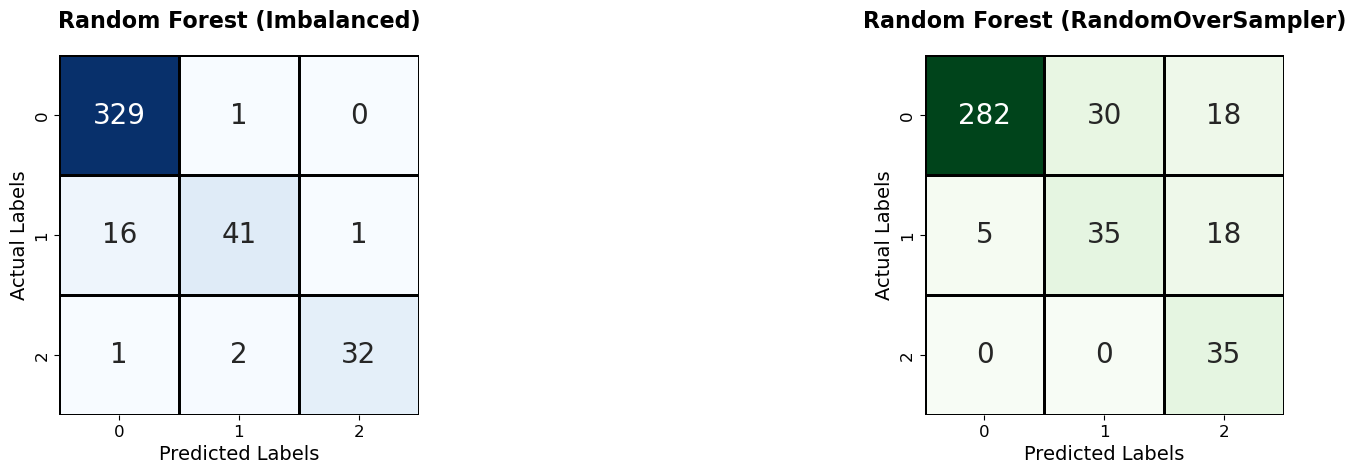

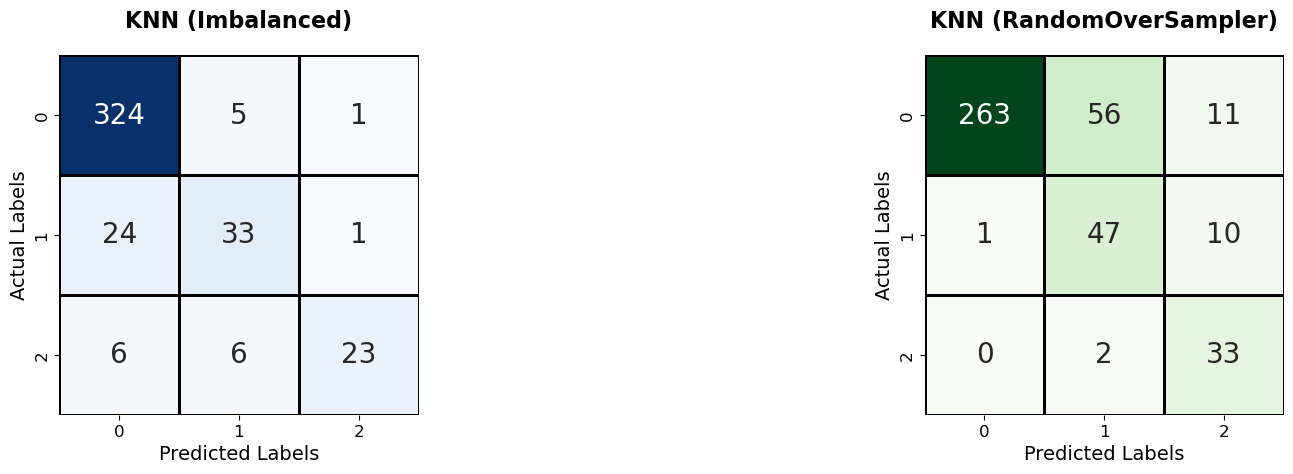

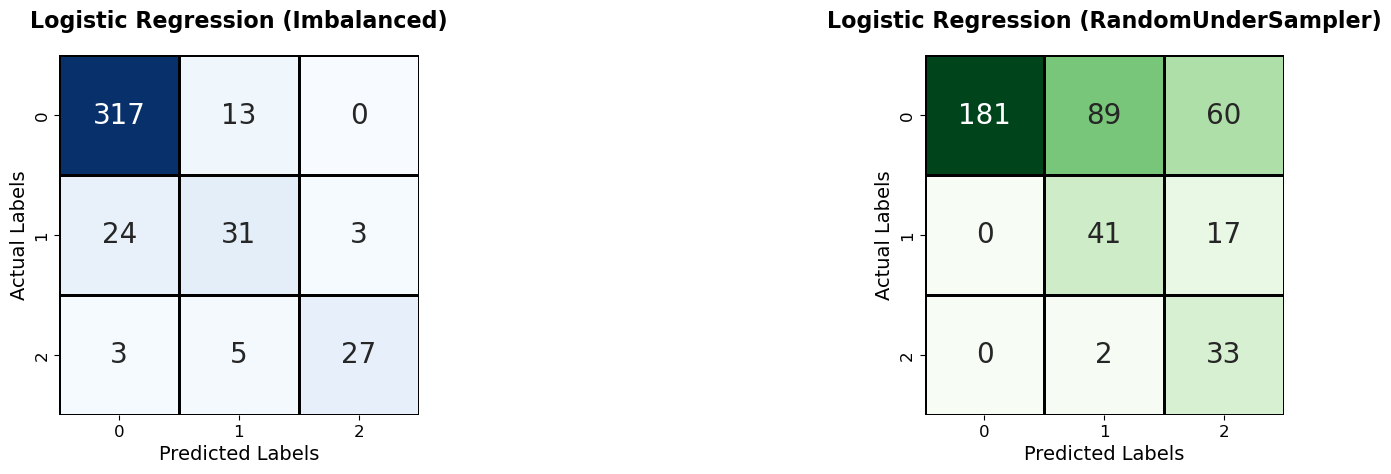

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize models
models = [RandomForestClassifier(random_state=42), KNeighborsClassifier(n_neighbors=5), LogisticRegression(random_state=42)]
model_names = ['Random Forest', 'KNN', 'Logistic Regression']
resamplers = [RandomOverSampler(random_state=42), RandomOverSampler(random_state=42), RandomUnderSampler(random_state=42)]
resampler_names = ['RandomOverSampler', 'RandomOverSampler', 'RandomUnderSampler']

# Loop through each model to display side-by-side plots
for (model, name, resampler, resampler_name) in zip(models, model_names, resamplers, resampler_names):
    plt.figure(figsize=(18, 15))
    # Train and predict on imbalanced data
    model.fit(X_train_scaled, y_train)
    y_pred_imbalanced = model.predict(X_test_scaled)
    conf_matrix_imbalanced = confusion_matrix(y_test, y_pred_imbalanced)
    
    # Resample and predict on balanced data
    X_resampled, y_resampled = resampler.fit_resample(X_train, y_train)
    X_resampled_scaled = scaler.fit_transform(X_resampled)
    model.fit(X_resampled_scaled, y_resampled)
    y_pred_balanced = model.predict(X_test_scaled)
    conf_matrix_balanced = confusion_matrix(y_test, y_pred_balanced)
    
    # Plot confusion matrix for imbalanced data
    plt.subplot(len(models), 2, 1)
    sns.heatmap(conf_matrix_imbalanced, annot=True, fmt='d', cmap='Blues', cbar=False,
                annot_kws={"size": 20}, linewidths=0.8, linecolor='black', square=True)
    plt.title(f"{name} (Imbalanced)", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Labels', fontsize=14)
    plt.ylabel('Actual Labels', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Plot confusion matrix for balanced data
    plt.subplot(len(models), 2, 2)
    sns.heatmap(conf_matrix_balanced, annot=True, fmt='d', cmap='Greens', cbar=False,
                annot_kws={"size": 20}, linewidths=0.8, linecolor='black', square=True)
    plt.title(f"{name} ({resampler_name})", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Labels', fontsize=14)
    plt.ylabel('Actual Labels', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout(pad=5.0)
    plt.show()


### **Overall Comparison**

For the **imbalanced dataset**, the Random Forest model had the best performance in terms of Recall and F1 Score, then the K-Nearest Neighbors model and finally the Logistic Regression model.
However, when we **balanced the dataset**, the K-Nearest Neighbors model had the best performance in terms of Recall and F1 Score, then the Random Forest model and finally the Logistic Regression model.

In general, we can observe that there has been a shift from overall prediction in the `Normal` class (majority class) to the `Pathological` and `Suspect` classes (minority classes). This is because the models are now more balanced, and therefore they are not biased towards making predictions in the majority class.

We can also observe that has been a decrease in the F1 Score for all models, which is expected, because the models are now more balanced, and therefore they are not biased towards making predictions in the majority class (decreasing accuracy). Recall has also decreased, but that is because it is taking into account False Negatives from the other classes, and not only the majority class. Coming back to the initial analysis, we want to prevent a fetus that is `Pathological`/`Suspicious` from being classified as `Normal`. With this in mind, we can say that the models are now better at classifying the minority classes, which is what we wanted to achieve.

## References

- Ayres de Campos et al. (2000) [SisPorto 2.0 A Program for Automated Analysis of Cardiotocograms.](https://onlinelibrary.wiley.com/doi/10.1002/1520-6661(200009/10)9:5%3C311::AID-MFM12%3E3.0.CO;2-9) J Matern Fetal Med 5:311-318
